In [ ]:
# Data Import and Cleaning

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

power_plants = pd.read_csv('global_power_plant_database.csv')

power_plants.info()



<class 'pandas.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  str    
 1   country_long                    34936 non-null  str    
 2   name                            34936 non-null  str    
 3   gppd_idnr                       34936 non-null  str    
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  str    
 8   other_fuel1                     1944 non-null   str    
 9   other_fuel2                     276 non-null    str    
 10  other_fuel3                     92 non-null     str    
 11  commissioning_year              17447 non-null  float64
 12  owner                           20868 non-n

C:\Users\Joseph\AppData\Local\Temp\ipykernel_20436\3074906469.py:5: DtypeWarning: Columns (0: other_fuel3) have mixed types. Specify dtype option on import or set low_memory=False.
  power_plants = pd.read_csv('global_power_plant_database.csv')


In [3]:
power_plants.head(5)


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [ ]:
# Exploratory Data Analysis:

# (mean, median, standard deviation) for numerical columns


generation_cols = [
    'generation_gwh_2013',
    'generation_gwh_2014',
    'generation_gwh_2015',
    'generation_gwh_2016',
    'generation_gwh_2017',
    'generation_gwh_2018',
    'generation_gwh_2019'
]

summary_generation = pd.DataFrame({
    'Year': [col[-4:] for col in generation_cols],
    'Mean_Gwh': power_plants[generation_cols].mean().values,
    'Median_Gwh': power_plants[generation_cols].median().values,
    'STD_Gwh':power_plants[generation_cols].std().values,
})

print(summary_generation)


   Year    Mean_Gwh  Median_Gwh      STD_Gwh
0  2013  592.696107   23.426000  2174.833482
1  2014  656.863891   23.608500  2231.464288
2  2015  762.368840   26.142000  2533.459828
3  2016  693.149763   22.462389  2404.516759
4  2017  661.834161   17.876500  2369.296957
5  2018  517.320785   12.530000  1975.302686
6  2019  423.922436   11.530000  1698.506485


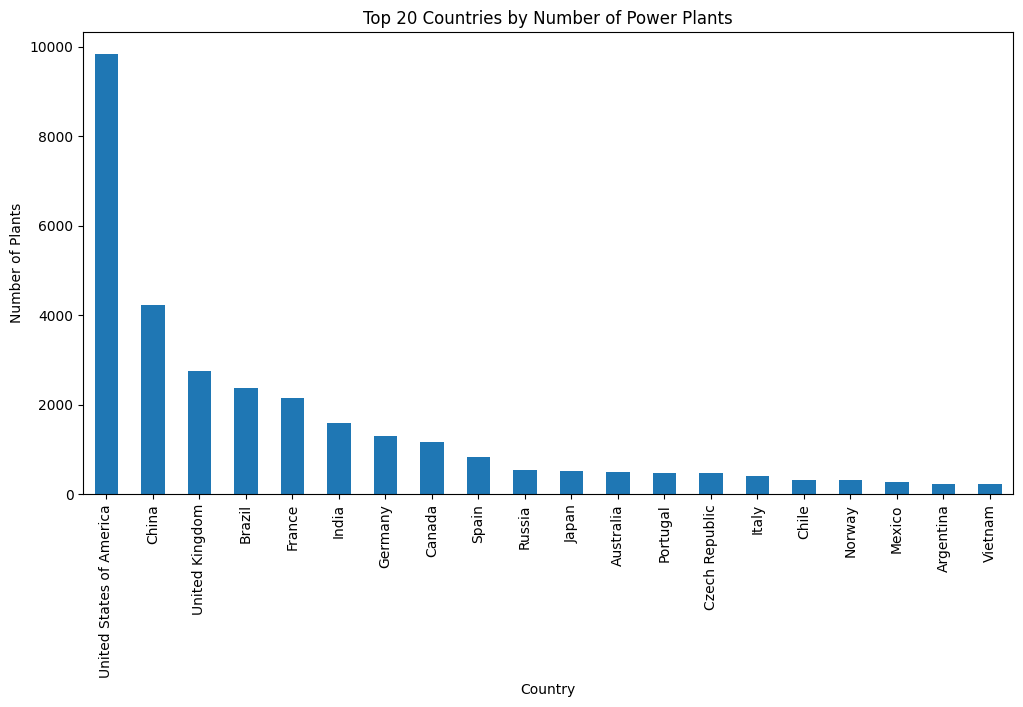

In [12]:
# the distribution of power plants by country and fuel type


country_counts = power_plants['country_long'].value_counts()

country_counts.head(20).plot(kind='bar', figsize=(12,6))
plt.title('Top 20 Countries by Number of Power Plants')
plt.ylabel('Number of Plants')
plt.xlabel('Country')
plt.show()

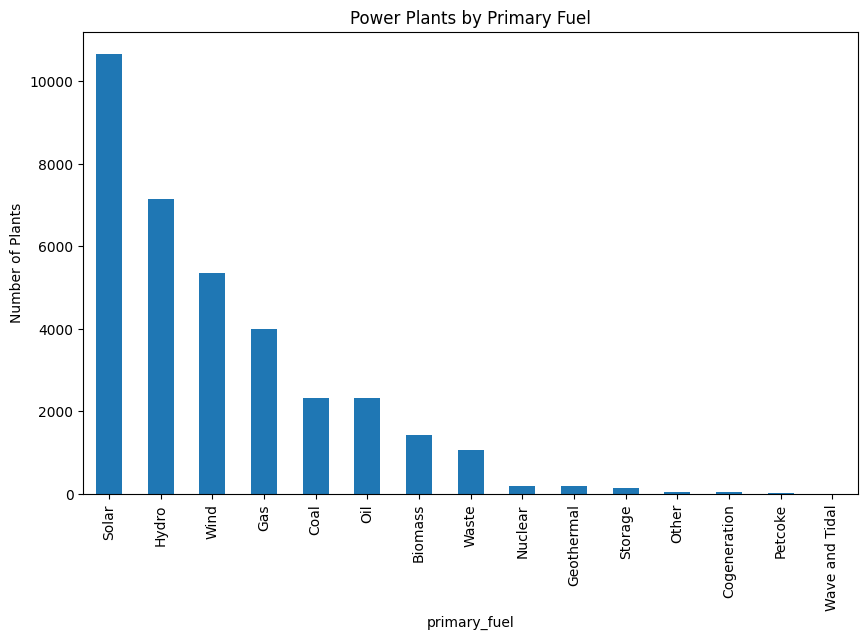

In [13]:


fuel_counts = power_plants['primary_fuel'].value_counts()

fuel_counts.plot(kind='bar', figsize=(10,6))
plt.title('Power Plants by Primary Fuel')
plt.ylabel('Number of Plants')
plt.show()

In [ ]:
# Perform a statistical analysis of power output by fuel type .
# Use hypothesis testing to determine if the mean power output differs significantly
#  between different fuel types.


